In [14]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from functools import reduce
from transformers import AutoModel, BertTokenizerFast, BertConfig, BertModel
import pickle
# import polars as pd
from data_utils import clean_feature_column, convert_id, combine_dfs, map_metab, normalize_data

import pickle

# MPS
if torch.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

In [2]:
gb_gene_exp = pd.read_excel(
    "data/glioblastoma/tabs_5_6_8_9_13_1-s2.0-S1535610821000507-mmc3.xlsx",
    parse_dates=False,
    sheet_name="gene_expression_fpkm_uq",
    engine="calamine",
)
gb_circ_rna = pd.read_excel(
    "data/glioblastoma/tabs_5_6_8_9_13_1-s2.0-S1535610821000507-mmc3.xlsx",
    parse_dates=False,
    sheet_name="circular_rna_fpkm_uq",
    engine="calamine",
)
gb_proteome = pd.read_excel(
    "data/glioblastoma/tabs_5_6_8_9_13_1-s2.0-S1535610821000507-mmc3.xlsx",
    parse_dates=False,
    sheet_name="proteome_normalized",
    engine="calamine",
)
gb_phosphoproteome = pd.read_excel(
    "data/glioblastoma/tabs_5_6_8_9_13_1-s2.0-S1535610821000507-mmc3.xlsx",
    parse_dates=False,
    sheet_name="phosphoproteome_normalized",
    engine="calamine",
)
gb_metabolome = pd.read_excel(
    "data/glioblastoma/tabs_5_6_8_9_13_1-s2.0-S1535610821000507-mmc3.xlsx",
    parse_dates=False,
    sheet_name="metabolome_normalized",
    engine="calamine",
)

In [3]:
kd_compound_metab = pd.read_excel(
    "data/kidney/compoundTab_metab_1-s2.0-S2666379124002398-mmc9.xlsx",
    parse_dates=False,
    sheet_name="compound_abundance",
    engine="calamine",
)
kd_rna_prot = pd.read_excel(
    "data/kidney/rna_prote_both_tabs1-s2.0-S2666379124002398-mmc3_RNAseqExpressionMX_proteinAbund_exprMX.xlsx",
    parse_dates=False,
    sheet_name="Abundance_gene_MD_protein",
    engine="calamine",
)
kd_rna = pd.read_excel(
    "data/kidney/rna_prote_both_tabs1-s2.0-S2666379124002398-mmc3_RNAseqExpressionMX_proteinAbund_exprMX.xlsx",
    parse_dates=False,
    sheet_name="TPM_filtered_log2_RNA",
    engine="calamine",
)

In [4]:
gb_gene_exp = clean_feature_column(gb_gene_exp, "gene_name")
gb_gene_exp = clean_feature_column(gb_gene_exp, "gene_id", strip_versions=True)
kd_rna = clean_feature_column(kd_rna, "ID")
kd_rna = convert_id(kd_rna, "ID", replace_col=True)

kd_rna_prot = clean_feature_column(kd_rna_prot, "ProteinID", strip_versions=True)

gb_metabolome = map_metab(gb_metabolome, "Metabolite", "metab_mapping.txt")
kd_compound_metab = map_metab(kd_compound_metab, "Name", "metab_mapping.txt")

In [5]:
gb_proteome = gb_proteome[
    ~gb_proteome.index.isin(["NumberPSM", "MaxPepProb", "ReferenceIntensity"])
]
gb_phosphoproteome = gb_phosphoproteome[
    ~gb_phosphoproteome.index.isin(["NumberPSM", "MaxPepProb", "ReferenceIntensity"])
]
kd_rna_prot = kd_rna_prot[
    ~kd_rna_prot.index.isin(["NumberPSM", "MaxPepProb", "ReferenceIntensity"])
]

In [6]:
def prepare_omics(df, feature_col, prefix):
    # this below was necessary as some columns were parsed as dates
    # convert feature column to string if it's not already
    df[feature_col] = df[feature_col].astype(str)
    df = df.set_index(feature_col)
    df = df.select_dtypes(include=["number"])
    df = df.T

    # add prefix to features (dup columns)
    ## Temporarily removing prefix
    # df.index = df.index.str.strip()
    # df.columns = [f"{prefix}_{c}" for c in df.columns]
    return df

In [7]:
gb_gene_exp = prepare_omics(gb_gene_exp, "gene_id", "GE")
gb_circ_rna = prepare_omics(gb_circ_rna, "gene_name", "CR")
gb_proteome = prepare_omics(gb_proteome, "symbol", "PR")
gb_phosphoproteome = prepare_omics(gb_phosphoproteome, "symbol", "PP")
gb_metabolome = prepare_omics(gb_metabolome, "Metabolite", "MB")

kd_compound_metab = prepare_omics(kd_compound_metab, "Name", "MB")
kd_rna_prot = prepare_omics(kd_rna_prot, "ProteinID", "PR")
kd_rna = prepare_omics(kd_rna, "ID", "GE")

In [8]:
# gb_gene_exp = normalize_data(gb_gene_exp)
# gb_circ_rna = normalize_data(gb_circ_rna)
# gb_proteome = normalize_data(gb_proteome)
# gb_phosphoproteome = normalize_data(gb_phosphoproteome)
# gb_metabolome = normalize_data(gb_metabolome)

# kd_compound_metab = normalize_data(kd_compound_metab)
# kd_rna_prot = normalize_data(kd_rna_prot)
# kd_rna = normalize_data(kd_rna)

In [9]:
# merged_ge = pd.read_csv("data/comb_rna.csv")
# merged_prot = pd.read_csv("data/comb_prot.csv")
# merged_metab = pd.read_csv("data/comb_metab.csv")


merged_ge = combine_dfs([kd_rna, gb_gene_exp])
merged_prot = combine_dfs([kd_rna_prot, gb_proteome])
merged_metab = combine_dfs([kd_compound_metab, gb_metabolome])

In [10]:
kd_rna

ID,ENSG00000121410,ENSG00000148584,ENSG00000175899,ENSG00000166535,ENSG00000256069,ENSG00000291190,ENSG00000184389,ENSG00000128274,ENSG00000118017,ENSG00000094914,...,ENSG00000122952,ENSG00000198205,ENSG00000198455,ENSG00000070476,ENSG00000203995,ENSG00000232242,ENSG00000162378,ENSG00000159840,ENSG00000274572,ENSG00000074755
C3L-00103-T,1.275001,2.659935,10.256962,1.118725,0.515844,0.515844,0.071853,4.586589,0.287286,4.875354,...,2.568689,3.214049,2.972207,4.741375,1.144901,0.000000,5.033445,5.143367,0.0,4.588955
C3L-00103-N,0.796481,5.006641,9.566704,1.304752,0.000000,0.000000,0.084953,4.785250,0.090784,5.093103,...,2.269537,2.995074,2.935058,5.324656,3.417318,0.000000,5.277762,4.735392,0.0,4.936948
C3L-00097-T,1.038773,3.920666,9.630731,0.899497,1.035146,1.035146,0.379324,5.006465,0.147476,4.948607,...,3.534304,3.428826,2.552225,4.552351,2.121828,0.000000,5.058021,4.468276,0.0,4.464406
C3L-00097-N,0.761946,5.575295,8.157933,1.400080,0.263551,0.263551,0.000000,4.293822,0.000000,5.038855,...,2.878612,2.868468,2.489278,5.183772,4.288018,0.237319,5.166213,3.851428,0.0,4.689777
C3L-00088-T,1.261218,5.524577,9.572729,1.292281,0.990882,0.990882,0.208980,5.159125,0.320450,5.192186,...,2.840136,3.541056,2.543380,4.945584,2.461819,0.000000,5.114663,4.130604,0.0,4.282502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C3N-02261-N,1.010054,5.575833,8.355858,1.701701,0.293352,0.293352,0.000000,4.448919,0.093729,5.422427,...,2.912290,3.105396,2.755524,5.489559,4.244138,0.970580,5.454709,4.549187,0.0,5.020575
C3N-02440-T,2.454242,0.437899,7.877695,1.616690,0.084260,0.084260,0.100920,4.409806,0.000000,5.367418,...,3.072576,3.108675,2.914038,4.770494,1.796381,0.000000,4.866592,5.950793,0.0,5.043625
C3N-02440-N,0.999217,5.748376,7.941388,1.452232,0.411814,0.411814,0.000000,5.006653,0.000000,5.249878,...,2.172097,3.001755,2.914071,5.422428,3.617693,0.000000,5.408155,4.892819,0.0,4.877285
C3N-02818-T,0.779845,1.831574,6.307235,1.308723,0.000000,0.000000,0.000000,5.383221,0.177039,5.674158,...,3.810913,2.918856,2.539524,4.766802,1.279335,0.000000,5.150763,6.056954,0.0,4.614833


In [12]:
matrix = []
labels = []
label_ids = []
for i in merged_ge.index:
    if i in merged_prot.index and i in merged_metab.index:
        labels.append(1 if i.endswith("T") else 0)
        label_ids.append(i)
        _l = []
        _l.extend(merged_ge.loc[i])
        _l.extend(merged_prot.loc[i])
        _l.extend(merged_metab.loc[i])
        matrix.append(_l)
matrix = np.array(matrix)

In [13]:
matrix.shape

(115, 74002)

In [15]:
with open("data/data_labels.pkl", "wb") as _f:
    pickle.dump(label_ids, _f)

In [14]:
cleaned_matrix = []
for i in range(matrix.shape[1]):
    _x = matrix[:, i]
    _x = np.nan_to_num(_x, nan=0.0)
    if np.all(_x == 0.0):
        continue
    cleaned_matrix.append(matrix[:, i])
cleaned_matrix = np.array(cleaned_matrix).T

In [15]:
merged_ge.shape

(348, 50455)

In [99]:
cleaned_matrix.shape

(115, 71094)

In [ ]:
with open("data/cleaned_data_matrix.pkl", "wb") as _f:
    pickle.dump(cleaned_matrix, _f)

In [93]:
matrix.shape

(115, 74002)

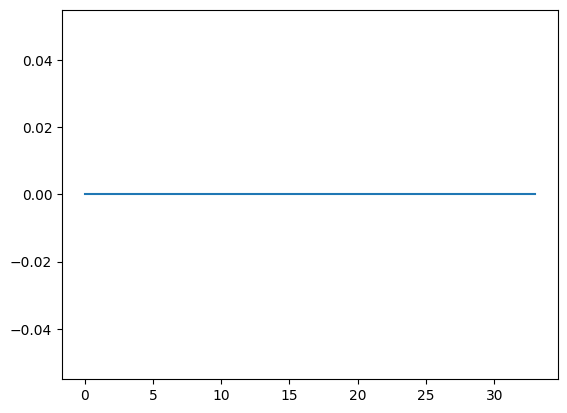

In [82]:
import matplotlib.pyplot as plt
plt.plot(matrix[:, 80])

In [15]:
len(labels)

115

In [16]:
import pickle

In [17]:
with open("data/zscore_comb_matrix_labels.pkl", "wb") as _f:
    pickle.dump([matrix, labels], _f)

In [98]:
cleaned_matrix = []
for i in range(matrix.shape[1]):
    _x = matrix[:, i]
    _x = np.nan_to_num(_x, nan=0.0)
    if np.all(_x == 0.0):
        continue
    cleaned_matrix.append(matrix[:, i])
cleaned_matrix = np.array(cleaned_matrix).T

In [99]:
cleaned_matrix.shape

(115, 71094)

In [ ]:
cleaned_matrix

In [100]:
import pickle
with open("data/cleaned_data_matrix.pkl", "wb") as _f:
    pickle.dump(cleaned_matrix, _f)

In [93]:
matrix.shape

(115, 74002)

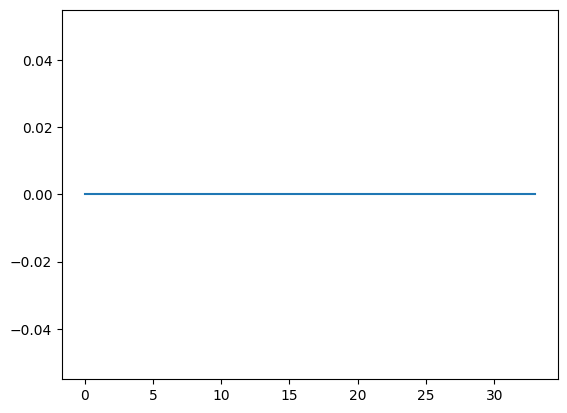

In [82]:
import matplotlib.pyplot as plt
plt.plot(matrix[:, 80])

In [15]:
len(labels)

115

In [16]:
import pickle

In [17]:
with open("data/zscore_comb_matrix_labels.pkl", "wb") as _f:
    pickle.dump([matrix, labels], _f)

In [24]:
## TODO: Testing just with kidney data first

median = np.nanmedian(matrix)
matrix = np.nan_to_num(matrix, nan=median)
rna_prot_vals = torch.log2(
    torch.abs(torch.fft.rfft(torch.FloatTensor(matrix), dim=1))[:, :512] + 1
)  ## Using log scaler to check improvement in perf.
# split train dataset into train, validation and test sets
train_text, temp_text, train_labels, temp_labels = train_test_split(
    rna_prot_vals,
    [1] * matrix.shape[0],
    random_state=42,  # ;)
    test_size=0.3,
)


val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text, temp_labels, random_state=42, test_size=0.5, stratify=temp_labels
)

tokens_train = train_text
tokens_val = val_text
tokens_test = test_text


max_len = 25

In [27]:
train_seq = torch.tensor(tokens_train)
train_mask = torch.ones_like(train_seq)
train_y = torch.tensor(train_labels)

val_seq = torch.tensor(tokens_val)
val_mask = torch.ones_like(val_seq)
val_y = torch.tensor(val_labels)

test_seq = torch.tensor(tokens_test)
test_mask = torch.ones_like(test_seq)
test_y = torch.tensor(test_labels)

/var/folders/fm/8nrzjtl506x96rlrk57yg4y40000gn/T/ipykernel_19323/3036122672.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train)
/var/folders/fm/8nrzjtl506x96rlrk57yg4y40000gn/T/ipykernel_19323/3036122672.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_seq = torch.tensor(tokens_val)
/var/folders/fm/8nrzjtl506x96rlrk57yg4y40000gn/T/ipykernel_19323/3036122672.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_seq = torch.tensor(tokens_test)


In [28]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# define a batch size
batch_size = 1

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

In [30]:
num_bins = 40

# get bert
bert_config = BertConfig()
bert = BertModel(bert_config)

# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

# (don't) freeze all the parameters
for param in bert.parameters():
    param.requires_grad = True

In [31]:
model = BERT_Arch_Fourier(bert)

model = model.to(device)

In [32]:
# optimizer from hugging face transformers
from torch.optim import AdamW

# define the optimizer
optimizer = AdamW(model.parameters(), lr=1e-5)

In [33]:
from sklearn.utils.class_weight import compute_class_weight

# compute the class weights
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_labels
)
print("Class Weights:", class_weights)

Class Weights: [1.]


In [34]:
# converting list of class weights to a tensor
weights = torch.tensor(class_weights, dtype=torch.float)

# push to GPU
weights = weights.to(device)

# define the loss function
cross_entropy = nn.NLLLoss(weight=weights)

# number of training epochs
epochs = 100

In [35]:
# function to train the model
def train():

    model.train()
    total_loss, total_accuracy = 0, 0

    # empty list to save model predictions
    total_preds = []

    # iterate over batches
    for step, batch in enumerate(train_dataloader):
        # progress update after every 50 batches.
        if step % 50 == 0 and not step == 0:
            print("  Batch {:>5,}  of  {:>5,}.".format(step, len(train_dataloader)))

        # push the batch to gpu
        batch = [r.to(device) for r in batch]

        sent_id, mask, labels = batch

        # clear previously calculated gradients
        model.zero_grad()

        # get model predictions for the current batch
        preds = model(sent_id, mask)

        # compute the loss between actual and predicted values
        loss = cross_entropy(preds, labels)

        # add on to the total loss
        total_loss = total_loss + loss.item()

        # backward pass to calculate the gradients
        loss.backward()

        # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update parameters
        optimizer.step()

        # model predictions are stored on GPU. So, push it to CPU
        preds = preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    # compute the training loss of the epoch
    avg_loss = total_loss / len(train_dataloader)

    # predictions are in the form of (no. of batches, size of batch, no. of classes).
    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds = np.concatenate(total_preds, axis=0)
    # returns the loss and predictions
    return avg_loss, total_preds

In [36]:
import time


# function for evaluating the model
def evaluate():

    print("\nEvaluating...")
    t0 = time.time()
    # deactivate dropout layers
    model.eval()

    total_loss, total_accuracy = 0, 0

    # empty list to save the model predictions
    total_preds = []

    # iterate over batches
    for step, batch in enumerate(val_dataloader):
        # Progress update every 50 batches.
        if step % 50 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = time.time() - t0

            # Report progress.
            print("  Batch {:>5,}  of  {:>5,}.".format(step, len(val_dataloader)))

        # push the batch to gpu
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        # deactivate autograd
        with torch.no_grad():
            # model predictions
            preds = model(sent_id, mask)

            # compute the validation loss between actual and predicted values
            loss = cross_entropy(preds, labels)

            total_loss = total_loss + loss.item()

            preds = preds.detach().cpu().numpy()

            total_preds.append(preds)

    # compute the validation loss of the epoch
    avg_loss = total_loss / len(val_dataloader)

    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds = np.concatenate(total_preds, axis=0)

    return avg_loss, total_preds

In [37]:
device

device(type='mps')

In [38]:
## TODO: Gives nan loss idk why

# set initial loss to infinite
best_valid_loss = float("inf")

# empty lists to store training and validation loss of each epoch
train_losses = []
valid_losses = []

# for each epoch
for epoch in range(1):
    print("\n Epoch {:} / {:}".format(epoch + 1, epochs))

    # train model
    train_loss, _ = train()

    # evaluate model
    valid_loss, _ = evaluate()

    # save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "saved_weights.pt")

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"\nTraining Loss: {train_loss:.3f}")
    print(f"Validation Loss: {valid_loss:.3f}")


 Epoch 1 / 100


RuntimeError: weight tensor should be defined either for all 512 classes or no classes but got weight tensor of shape: [1]

In [ ]:
# load weights of best model
path = "saved_weights.pt"
model.load_state_dict(torch.load(path))

In [ ]:
# get predictions for test data
with torch.no_grad():
    preds = model(test_seq.to(device), test_mask.to(device))
    preds = preds.detach().cpu().numpy()

In [ ]:
# model's performance
preds = np.argmax(preds, axis=1)
print(classification_report(test_y, preds))